In [2]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.strategies.features import compute_features

# Load data
data = load_multiple_tickers(NIFTY_50, "2015-01-01", "2024-12-31")
prices = get_close_prices(data).dropna(axis=1, how="all")

# Compute features
features = compute_features(prices)

print(f"Shape: {features.shape}")
print(f"Columns: {list(features.columns)}")
print(f"Date range: {features['date'].min().date()} to {features['date'].max().date()}")
print(f"Number of unique tickers: {features['ticker'].nunique()}")
print(f"\nFirst 5 rows:")
print(features.head())
print(f"\nLast 5 rows:")
print(features.tail())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading RELIANCE.NS ...
Cache for RELIANCE.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading TCS.NS ...
Cache for TCS.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading INFY.NS ...
Cache for INFY.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache (2014-01-01 to 2025-12-30)
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache (2014-01-01 to 2025-12-30)
Loading ITC.NS ...
Loading ITC.NS from cache (2014-01-01 to 2025-12-30)
L

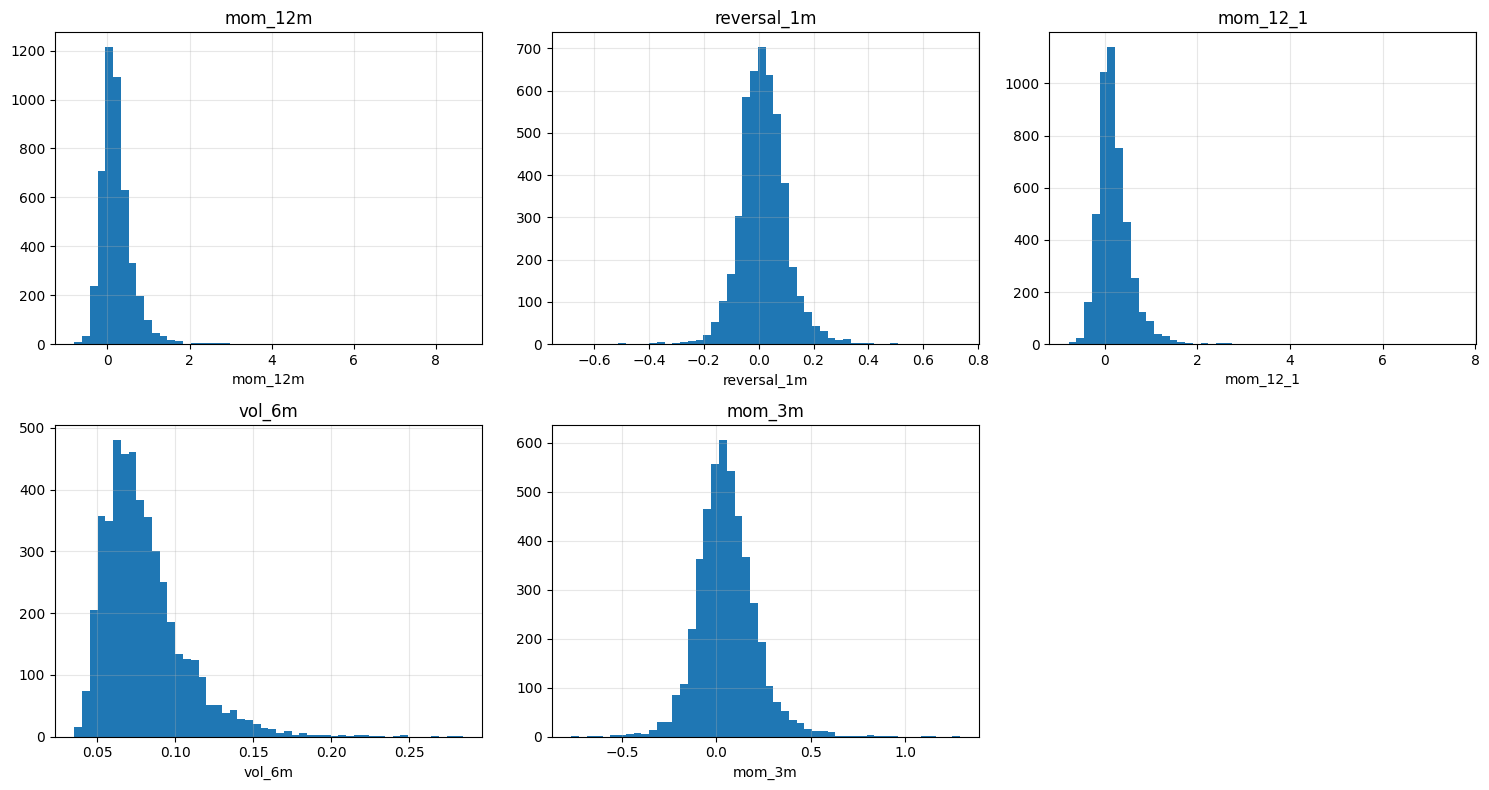

         mom_12m  reversal_1m   mom_12_1     vol_6m     mom_3m
count  4685.0000    4685.0000  4685.0000  4685.0000  4685.0000
mean      0.2318       0.0174     0.2105     0.0799     0.0533
std       0.4612       0.0883     0.4274     0.0261     0.1570
min      -0.8061      -0.6818    -0.7802     0.0353    -0.7674
25%      -0.0189      -0.0351    -0.0235     0.0621    -0.0419
50%       0.1612       0.0140     0.1465     0.0746     0.0420
75%       0.3850       0.0655     0.3571     0.0913     0.1378
max       8.6483       0.7326     7.6023     0.2841     1.2870


In [3]:
import matplotlib.pyplot as plt

feature_cols = ["mom_12m", "reversal_1m", "mom_12_1", "vol_6m", "mom_3m"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    features[col].hist(bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.grid(True, alpha=0.3)

# Hide the unused subplot
axes.flat[5].set_visible(False)

plt.tight_layout()
plt.show()

# Numerical summary
print(features[feature_cols].describe().round(4))

In [4]:
print("\nFeature correlations:")
print(features[feature_cols].corr().round(3))


Feature correlations:
             mom_12m  reversal_1m  mom_12_1  vol_6m  mom_3m
mom_12m        1.000        0.234     0.969   0.063   0.456
reversal_1m    0.234        1.000     0.008   0.099   0.543
mom_12_1       0.969        0.008     1.000   0.045   0.338
vol_6m         0.063        0.099     0.045   1.000   0.100
mom_3m         0.456        0.543     0.338   0.100   1.000


### target variable testing


In [5]:
from backtester.strategies.features import compute_target

features_with_target = compute_target(prices, features)

print(f"Shape: {features_with_target.shape}")
print(f"\nFirst 5 rows:")
print(features_with_target.head())
print(f"\nTarget distribution:")
print(features_with_target["target"].value_counts())
print(f"\nFraction that beat median: {features_with_target['target'].mean():.3f}")

Shape: (4641, 10)

First 5 rows:
        date        ticker   mom_12m  reversal_1m  mom_12_1    vol_6m  \
0 2016-01-31   RELIANCE.NS  0.145529     0.020501  0.122516  0.086619   
1 2016-01-31        TCS.NS -0.021032    -0.016320 -0.004790  0.055321   
2 2016-01-31   HDFCBANK.NS -0.018201    -0.029848  0.012005  0.048334   
3 2016-01-31       INFY.NS  0.114374     0.053826  0.057455  0.076796   
4 2016-01-31  ICICIBANK.NS -0.350962    -0.119380 -0.262976  0.090501   

     mom_3m  next_month_return  median_return  target  
0  0.092540          -0.066400       -0.07378       1  
1 -0.039323          -0.089700       -0.07378       0  
2 -0.045244          -0.074296       -0.07378       0  
3  0.025937          -0.069405       -0.07378       1  
4 -0.169133          -0.174234       -0.07378       0  

Target distribution:
target
0    2321
1    2320
Name: count, dtype: int64

Fraction that beat median: 0.500


In [6]:
features_with_target.to_csv("../reports/ml_features.csv", index=False)
print("Saved features to reports/ml_features.csv")

Saved features to reports/ml_features.csv
